# TEAM 04 — Ames Housing: Does Adding More Features Improve Prediction?
## An Investigation of Informative, Irrelevant, and Redundant Features

**Research Question:** Does adding more features necessarily improve prediction?

**Required structure:** Question → Hypothesis → Experiment → Evidence → Analysis → Conclusion

---

## Team Contributions

| Member | Area | Source file |
|---|---|---|
| Member 1 | Experimental Design & Feature Construction | `src/feature_sets.py` |
| Member 2 | Data Processing & Preprocessing | `src/data.py`, `src/preprocessing.py` |
| Member 3 | Model Behaviour | `src/models.py`, `src/experiments.py` |
| Member 4 | Validation, Metrics & Statistical Analysis | `src/validation.py`, `src/analysis.py` |


## 0. Imports and Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)


---
# MEMBER 1 — Experimental Design & Feature Construction
**File:** `src/feature_sets.py`  
**Branch:** `feature/member1-feature-design`

## Hypotheses (defined before modeling)

| Hypothesis | Experiment | Expected direction |
|---|---|---|
| H1 — Meaningful features improve performance | M10 → M20 | RMSE down |
| H2 — Irrelevant features do NOT improve | M20 → M20+I | RMSE up or flat |
| H3 — Redundant features add no new information | M20 → M20+R | RMSE flat |
| H4 — Combined exposes model-specific sensitivity | M20 → M20+I+R | Model-dependent |


### 1.1 Feature lists

In [2]:
from src.feature_sets import (
    M10_FEATURES, M20_FEATURES,
    IRRELEVANT_FEATURE_NAMES, REDUNDANT_FEATURE_NAMES,
    REDUNDANT_SPECS,
    add_irrelevant_features, add_redundant_features,
    build_feature_configs, redundancy_correlation_table,
)

print(f"M10 features ({len(M10_FEATURES)}):")
for f in M10_FEATURES:
    print(f"  {f}")

print(f"\nM20 features ({len(M20_FEATURES)}):")
for f in M20_FEATURES:
    mark = "  " if f in M10_FEATURES else "+ "
    print(f"  {mark}{f}")


M10 features (10):
  Overall Qual
  Gr Liv Area
  Garage Cars
  Total Bsmt SF
  1st Flr SF
  Year Built
  Year Remod/Add
  Full Bath
  TotRms AbvGrd
  Garage Area

M20 features (20):
    Overall Qual
    Gr Liv Area
    Garage Cars
    Total Bsmt SF
    1st Flr SF
    Year Built
    Year Remod/Add
    Full Bath
    TotRms AbvGrd
    Garage Area
  + Overall Cond
  + Bedroom AbvGr
  + Fireplaces
  + Garage Yr Blt
  + Mas Vnr Area
  + BsmtFin SF 1
  + Lot Area
  + Neighborhood
  + Kitchen Qual
  + Central Air


### 1.2 Experiment configuration table

In [3]:
config_doc = {
    "M10":     ("10 meaningful",               "Secondary: H1 meaningful gain"),
    "M20":     ("20 meaningful",               "PRIMARY BASELINE for H2/H3/H4"),
    "M20_I":   ("20 meaningful + 10 irrel.",   "Main experiment: H2"),
    "M20_R":   ("20 meaningful + 5 redund.",   "Main experiment: H3"),
    "M20_I_R": ("20 meaningful + both",        "Main experiment: H4"),
    "ALL":     ("All original features",       "Contextual only — NOT main baseline"),
}
pd.DataFrame.from_dict(
    config_doc, orient="index",
    columns=["Contents", "Role"]
)


,Contents,Role
M10,10 meaningful,Secondary: H1 meaningful gain
M20,20 meaningful,PRIMARY BASELINE for H2/H3/H4
M20_I,20 meaningful + 10 irrel.,Main experiment: H2
M20_R,20 meaningful + 5 redund.,Main experiment: H3
M20_I_R,20 meaningful + both,Main experiment: H4
ALL,All original features,Contextual only — NOT main baseline


---
# MEMBER 2 — Data Processing & Preprocessing
**Files:** `src/data.py`, `src/preprocessing.py`  
**Branch:** `feature/member2-preprocessing`


### 2.1 Load and inspect data

In [4]:
from src.data import load_data, inspect_data, recode_absence_nans, prepare_XY, make_train_test_split

df_raw = load_data("data/raw/train.csv")
inspect_data(df_raw)


Loaded: 2930 rows x 82 columns
Rows     : 2930
Columns  : 82
SalePrice present: True
Duplicates: 0
Top missing columns:
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80


### 2.2 Recode absence NaNs (Ames-specific semantics)

> In the Ames dataset, NaN does not always mean unknown.
> For garage columns, NaN means the house has no garage.
> Categorical absence -> "None" | Numerical absence -> 0


In [5]:
df = recode_absence_nans(df_raw)

missing_after = df.isnull().sum()
missing_after = missing_after[missing_after > 0].sort_values(ascending=False)
print("Remaining genuine unknowns after absence recoding:")
display(missing_after.head(20).to_frame("RemainingMissing"))


Remaining genuine unknowns after absence recoding:


,RemainingMissing
Lot Frontage,490
Electrical,1


### 2.3 Separate predictors / remove identifiers

In [6]:
X, y = prepare_XY(df)

# Confirm that Order, PID, Id, SalePrice are NOT in X
for col in ["Order", "PID", "Id", "SalePrice"]:
    print(f"  {col} in X: {col in X.columns}")


Predictor shape: (2930, 79)  |  Dropped: ['SalePrice', 'Order', 'PID']
  Order in X: False
  PID in X: False
  Id in X: False
  SalePrice in X: False


### 2.4 Fixed 80/20 train/test split

In [7]:
X_train, X_test, y_train, y_test = make_train_test_split(X, y)


Train: 2344  |  Test: 586


### 2.5 Add synthetic features to full dataset

In [8]:
X_experiment = add_irrelevant_features(X)
X_experiment = add_redundant_features(X_experiment)

print(f"X shape before synthetic: {X.shape}")
print(f"X shape after synthetic:  {X_experiment.shape}")


X shape before synthetic: (2930, 79)
X shape after synthetic:  (2930, 94)


### 2.6 Verify redundant feature construction

In [9]:
redund_corr_table = redundancy_correlation_table(X_experiment)
print("Redundant feature Pearson correlations with originals:")
display(redund_corr_table)


Redundant feature Pearson correlations with originals:


,Original Feature,Redundant Feature,Multiplier,Noise SD,Pearson r
0,Gr Liv Area,Redundant_GrLivArea,1.02,10.0,0.9998
1,Overall Qual,Redundant_OverallQual,1.00,0.2,0.9900
2,Garage Area,Redundant_GarageArea,1.01,5.0,0.9997
3,Total Bsmt SF,Redundant_TotalBsmtSF,0.99,10.0,0.9998
4,Year Built,Redundant_YearBuilt,1.00,2.0,0.9978


### 2.7 Preprocessing pipeline design

| Step | Numerical | Categorical |
|---|---|---|
| Imputation | Median (genuine unknowns) | Most-frequent |
| Scaling | StandardScaler (Ridge only) | No scaling |
| Encoding | No encoding | OneHotEncoder |

Pipeline enforces that all statistics are learned from training folds only — no leakage.


---
# MEMBER 3 — Model Behaviour
**Files:** `src/models.py`, `src/experiments.py`  
**Branch:** `feature/member3-models`


### 3.1 Model configurations

**Ridge(alpha=10):** L2 regularized linear model.
Sensitive to multicollinearity; requires StandardScaler.

**RandomForestRegressor(n_estimators=300, max_features="sqrt"):**
Non-linear tree ensemble. Scale-invariant.
max_features="sqrt" means each split considers sqrt(n_features) candidates.
Code and explanation are consistent (handoff spec section 18).


In [10]:
from src.models import make_models

models = make_models()
for name, m in models.items():
    print(f"{name}: {m}")


Ridge: Ridge(alpha=10.0)
Random Forest: RandomForestRegressor(max_features='sqrt', n_estimators=300, n_jobs=-1,
                      random_state=42)


### 3.2 Build feature configurations

In [11]:
all_original_cols = list(X.columns)
feature_configs = build_feature_configs(all_original_cols)

config_summary = pd.DataFrame([
    {"Config": name, "Features": len(feats)}
    for name, feats in feature_configs.items()
])
display(config_summary)


,Config,Features
0,M10,10
1,M20,20
2,M20_I,30
3,M20_R,25
4,M20_I_R,35
5,ALL,79


### 3.3 Run experiments on fixed train/test split

In [12]:
from src.experiments import run_all_experiments, compute_pairwise_deltas

print("Running all configurations x models on fixed split...")
results_df = run_all_experiments(
    X_experiment, X_train, X_test, y_train, y_test, all_original_cols
)

display(
    results_df[
        ["Config","Model","Raw_Features","Train_RMSE","Test_RMSE","Test_MAE","Test_R2","Generalization_Gap"]
    ].sort_values(["Model","Config"]).round(2)
)


Running all configurations x models on fixed split...


,Config,Model,Raw_Features,Train_RMSE,Test_RMSE,Test_MAE,Test_R2,Generalization_Gap
0,M10,Random Forest,10,10468.01,30757.15,17797.32,0.88,20289.14
1,M20,Random Forest,20,9356.01,27035.47,15247.76,0.91,17679.46
2,M20_I,Random Forest,30,9951.01,28657.79,16205.06,0.90,18706.79
3,M20_R,Random Forest,25,9591.47,27231.81,15311.47,0.91,17640.35
4,M20_I_R,Random Forest,35,9862.64,27940.22,16017.71,0.90,18077.59
5,ALL,Random Forest,79,10206.14,27917.39,15933.06,0.90,17711.26
6,M10,Ridge,10,35290.66,39554.82,24840.44,0.80,4264.16
7,M20,Ridge,20,28953.04,32241.95,18619.74,0.87,3288.91
8,M20_I,Ridge,30,28912.49,32255.77,18696.44,0.87,3343.29
9,M20_R,Ridge,25,28952.40,32334.89,18682.92,0.87,3382.50


### 3.4 Pairwise delta analysis (single split)

In [13]:
delta_df = compute_pairwise_deltas(results_df)

print("Pairwise delta RMSE (positive = worse, negative = better):")
display(delta_df.round(2))


Pairwise delta RMSE (positive = worse, negative = better):


,Model,Comparison,Description,Delta_Test_RMSE,Delta_Test_MAE,Delta_Test_R2,Delta_Gen_Gap
0,Random Forest,M10 → M20,M10 → M20: adding meaningful features (H1),-3721.68,-2549.56,0.03,-2609.68
1,Ridge,M10 → M20,M10 → M20: adding meaningful features (H1),-7312.86,-6220.69,0.07,-975.24
2,Random Forest,M20 → M20_I,M20 → M20+I: adding irrelevant features (H2),1622.32,957.30,-0.01,1027.33
3,Ridge,M20 → M20_I,M20 → M20+I: adding irrelevant features (H2),13.82,76.70,-0.00,54.37
4,Random Forest,M20 → M20_R,M20 → M20+R: adding redundant features (H3),196.34,63.71,-0.00,-39.11
5,Ridge,M20 → M20_R,M20 → M20+R: adding redundant features (H3),92.94,63.17,-0.00,93.58
6,Random Forest,M20 → M20_I_R,M20 → M20+I+R: adding both (H4),904.75,769.94,-0.01,398.13
7,Ridge,M20 → M20_I_R,M20 → M20+I+R: adding both (H4),29.16,80.55,-0.00,67.96


---
# MEMBER 4 — Validation, Metrics & Statistical Analysis
**Files:** `src/validation.py`, `src/analysis.py`  
**Branch:** `feature/member4-validation`


### 4.1 Cross-validation design

**5-fold CV using the SAME KFold object for every configuration.**

The same folds enable a paired comparison: delta RMSE between M20 and M20+I
on fold k is attributable to the feature change, not random fold variation.

The final test set (20%) is never used during CV.


### 4.2 Run 5-fold cross-validation

In [14]:
from src.validation import run_cross_validation, compute_cv_deltas, cv_summary_table

print("Running 5-fold CV for all configurations x models...")
print("(This may take 1-2 minutes for Random Forest)")

cv_df = run_cross_validation(X_experiment, X_train, y_train, all_original_cols)


Running 5-fold CV for all configurations x models...
(This may take 1-2 minutes for Random Forest)
  CV done: M10
  CV done: M20
  CV done: M20_I
  CV done: M20_R
  CV done: M20_I_R
  CV done: ALL


### 4.3 CV results: mean plus/minus SD

In [15]:
cv_summary = cv_summary_table(cv_df)

print("Cross-Validation Summary (mean +/- SD across 5 folds):")
display(cv_summary.sort_values(["Model","Config"]).round(2))


Cross-Validation Summary (mean +/- SD across 5 folds):


,Config,Model,Raw_Features,CV_RMSE_Mean,CV_RMSE_SD,CV_MAE_Mean,CV_MAE_SD,CV_R2_Mean,CV_R2_SD
11,ALL,Random Forest,79,27141.55,5670.89,16166.06,1613.70,0.87,0.05
1,M10,Random Forest,10,28735.69,5768.14,18456.53,1775.81,0.86,0.06
3,M20,Random Forest,20,25818.22,6218.81,15993.12,1831.15,0.88,0.06
5,M20_I,Random Forest,30,27106.32,5927.58,16721.66,1851.77,0.87,0.06
9,M20_I_R,Random Forest,35,27283.94,6443.38,16768.31,1835.79,0.87,0.06
7,M20_R,Random Forest,25,26647.17,6830.77,16246.44,1851.75,0.87,0.07
10,ALL,Ridge,79,29656.31,10626.00,16523.59,1194.02,0.84,0.13
0,M10,Ridge,10,35821.21,7933.21,23217.41,1545.77,0.78,0.10
2,M20,Ridge,20,30553.81,9823.68,18291.24,1728.80,0.83,0.12
4,M20_I,Ridge,30,30653.05,9828.15,18348.61,1704.73,0.83,0.12


### 4.4 CV pairwise deltas with 95% confidence intervals

In [16]:
cv_delta_df = compute_cv_deltas(cv_df)

print("CV Pairwise delta RMSE with 95% CI:")
print("If CI does not cross 0, effect is consistent across folds.")
display(cv_delta_df)


CV Pairwise delta RMSE with 95% CI:
If CI does not cross 0, effect is consistent across folds.


,Model,Comparison,Description,Mean d RMSE,SD d RMSE,CI Lower,CI Upper
0,Ridge,M10 → M20,M10 → M20 (H1: meaningful features),-5267.41,2285.48,-8105.21,-2429.60
1,Random Forest,M10 → M20,M10 → M20 (H1: meaningful features),-2917.47,905.09,-4041.28,-1793.65
2,Ridge,M20 → M20_I,M20 → M20+I (H2: irrelevant),99.25,94.84,-18.52,217.01
3,Random Forest,M20 → M20_I,M20 → M20+I (H2: irrelevant),1288.10,997.48,49.56,2526.64
4,Ridge,M20 → M20_R,M20 → M20+R (H3: redundant),4.25,39.57,-44.88,53.38
5,Random Forest,M20 → M20_R,M20 → M20+R (H3: redundant),828.95,664.39,4.00,1653.90
6,Ridge,M20 → M20_I_R,M20 → M20+I+R (H4: both),109.49,103.02,-18.43,237.40
7,Random Forest,M20 → M20_I_R,M20 → M20+I+R (H4: both),1465.72,817.27,450.95,2480.50


### 4.5 Plot 1 — RMSE by feature configuration

Saved: results/figures\plot1_rmse_by_config.png


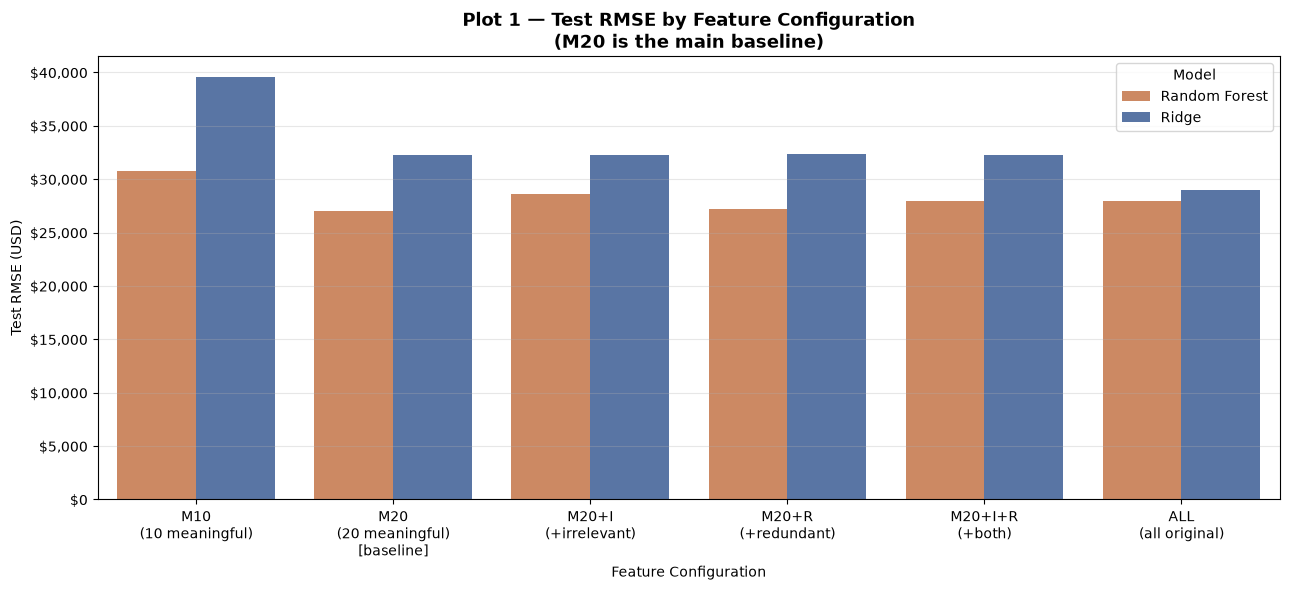

In [17]:
from src.analysis import (
    plot_rmse_by_config, plot_generalization,
    plot_cv_distribution, plot_delta_rmse,
    plot_feature_count_vs_rmse, plot_redundancy_heatmap,
    build_evidence_table,
)

plot_rmse_by_config(results_df)


### 4.6 Plot 2 — Train vs CV vs Test RMSE (generalization)

Saved: results/figures\plot2_generalization.png


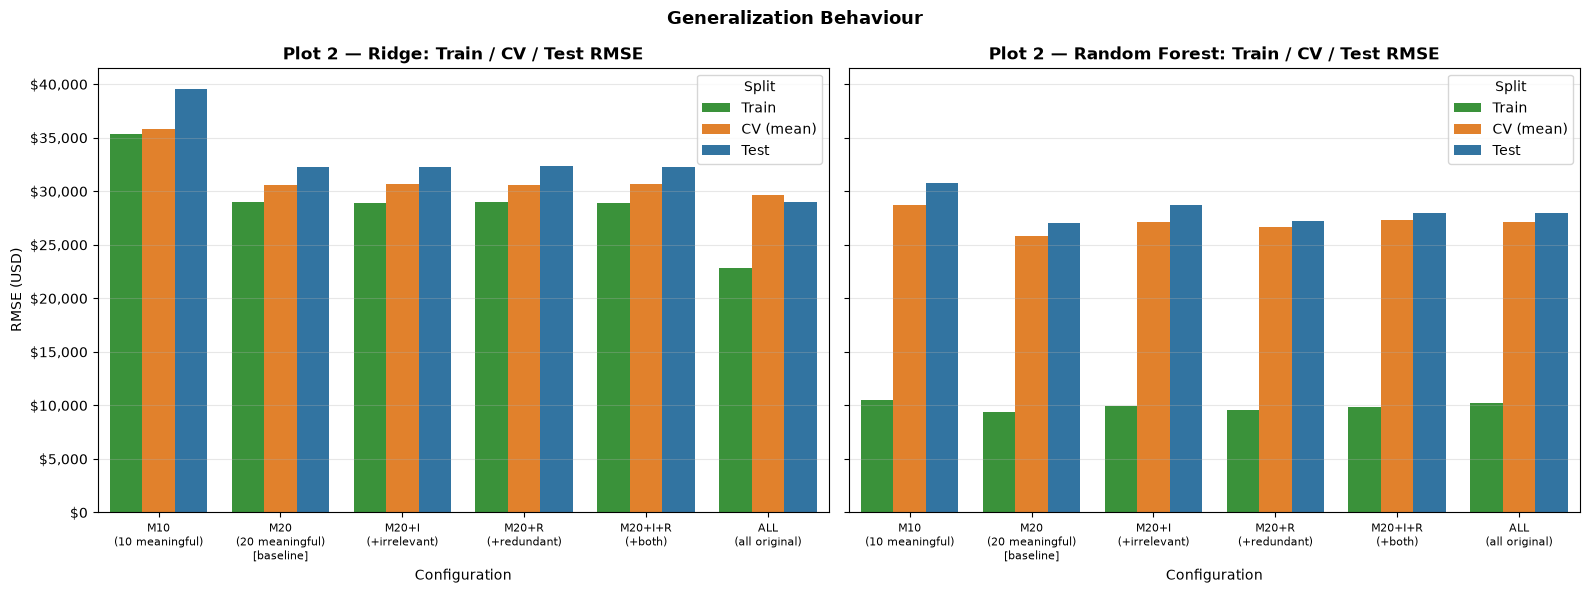

In [18]:
plot_generalization(results_df, cv_df)


### 4.7 Plot 3 — CV RMSE distribution across folds

Saved: results/figures\plot3_cv_distribution.png


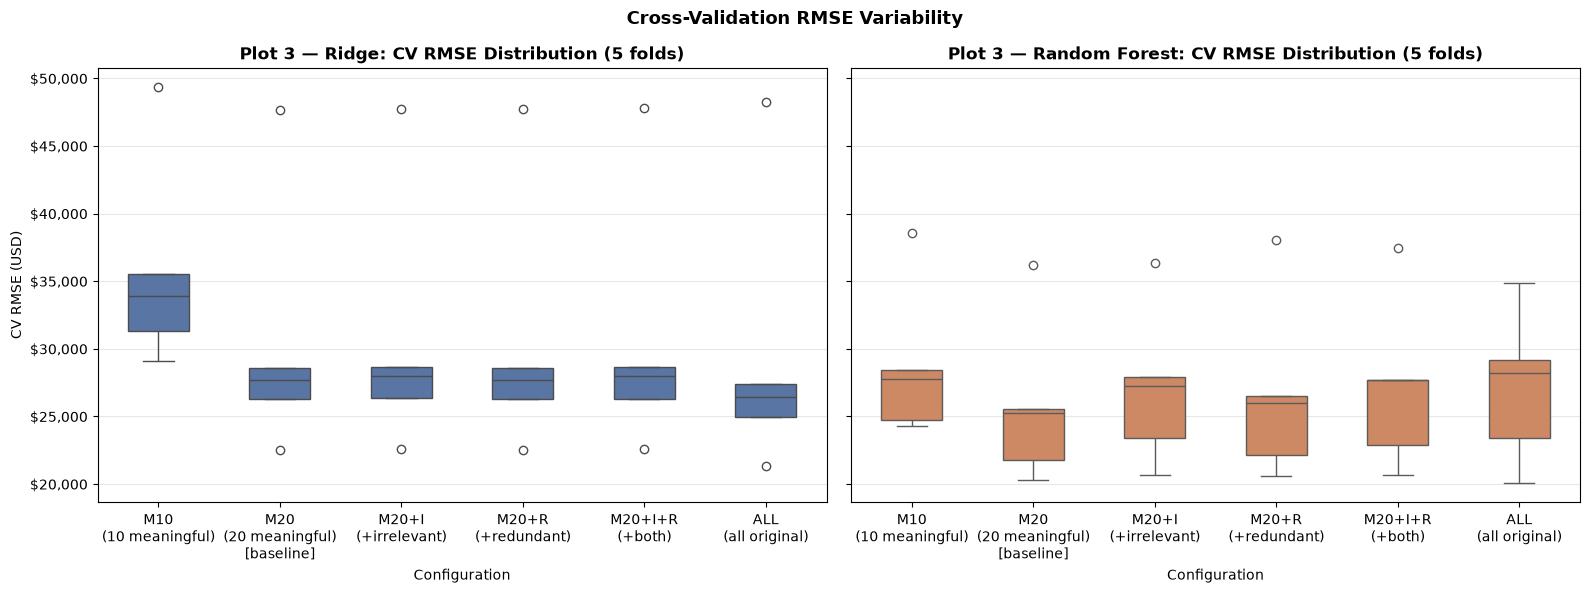

In [19]:
plot_cv_distribution(cv_df)


### 4.8 Plot 4 — Pairwise delta RMSE

Saved: results/figures\plot4_delta_rmse.png


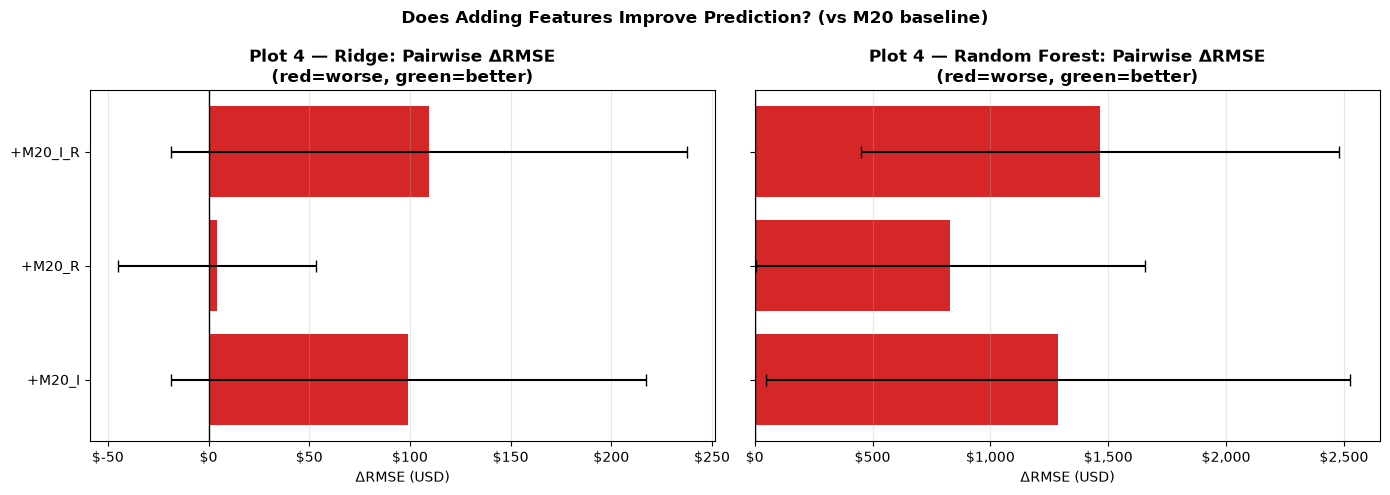

In [20]:
plot_delta_rmse(cv_delta_df)


### 4.9 Plot 5 — Feature count vs Test RMSE

Saved: results/figures\plot5_feature_count_vs_rmse.png


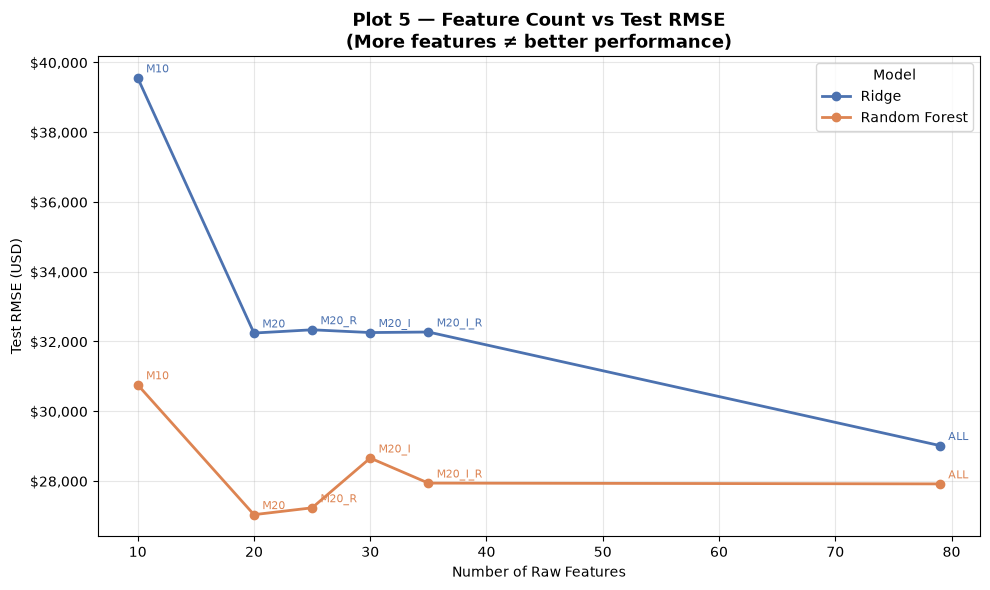

In [21]:
plot_feature_count_vs_rmse(results_df)


### 4.10 Redundancy heatmap

Saved: results/figures\plot_redundancy_heatmap.png


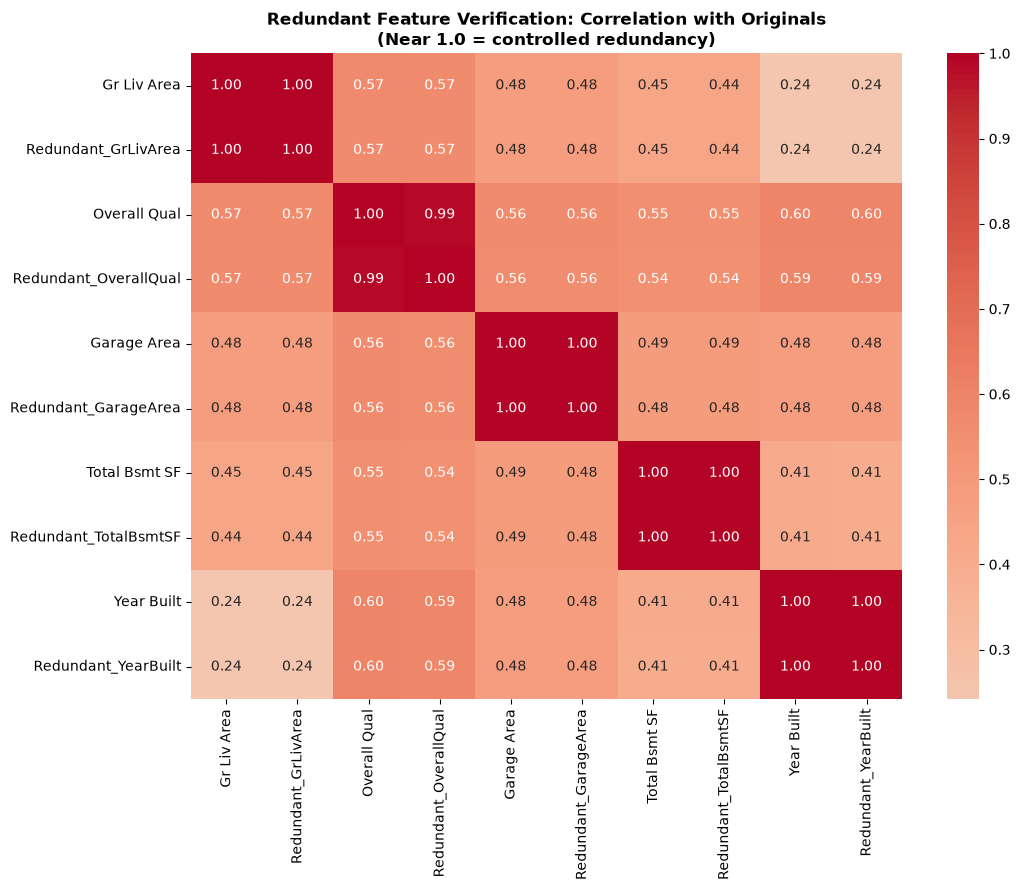

In [22]:
plot_redundancy_heatmap(X_experiment, REDUNDANT_SPECS)


### 4.11 Save final evidence tables

In [23]:
evidence_table = build_evidence_table(results_df, cv_df, delta_df, cv_delta_df)
print("Evidence table saved.")
display(evidence_table.round(2))


Saved: results/tables/evidence_table.csv
Saved: results/tables/pairwise_deltas.csv
Saved: results/tables/cv_pairwise_deltas.csv
Evidence table saved.


,Config,Model,Raw_Features,Test_RMSE,Test_MAE,Test_R2,Train_RMSE,Generalization_Gap,CV_RMSE_Mean,CV_RMSE_SD,CV_R2_Mean,CV_R2_SD
0,M10,Random Forest,10,30757.15,17797.32,0.88,10468.01,20289.14,28735.69,5768.14,0.86,0.06
1,M20,Random Forest,20,27035.47,15247.76,0.91,9356.01,17679.46,25818.22,6218.81,0.88,0.06
2,M20_I,Random Forest,30,28657.79,16205.06,0.90,9951.01,18706.79,27106.32,5927.58,0.87,0.06
3,M20_R,Random Forest,25,27231.81,15311.47,0.91,9591.47,17640.35,26647.17,6830.77,0.87,0.07
4,M20_I_R,Random Forest,35,27940.22,16017.71,0.90,9862.64,18077.59,27283.94,6443.38,0.87,0.06
5,ALL,Random Forest,79,27917.39,15933.06,0.90,10206.14,17711.26,27141.55,5670.89,0.87,0.05
6,M10,Ridge,10,39554.82,24840.44,0.80,35290.66,4264.16,35821.21,7933.21,0.78,0.10
7,M20,Ridge,20,32241.95,18619.74,0.87,28953.04,3288.91,30553.81,9823.68,0.83,0.12
8,M20_I,Ridge,30,32255.77,18696.44,0.87,28912.49,3343.29,30653.05,9828.15,0.83,0.12
9,M20_R,Ridge,25,32334.89,18682.92,0.87,28952.40,3382.50,30558.06,9857.83,0.83,0.12


---
# Analysis and Conclusions

> Complete this section after running the notebook and obtaining results.

## H1 — Did adding meaningful features (M10 to M20) improve performance?
*(Report delta RMSE, interpret direction)*

## H2 — Did adding irrelevant features (M20 to M20+I) hurt or help?
*(Compare Ridge vs RF reaction)*

## H3 — Did redundant features (M20 to M20+R) add information?
*(Near-zero delta expected)*

## H4 — Did the combined set (M20 to M20+I+R) behave differently?
*(Check for additive vs non-additive effects)*

## Conclusion

> Under the controlled experimental conditions, ...
> (Complete based on evidence — avoid absolute claims)

## Limitations

1. Results are specific to the Ames dataset.
2. Synthetic redundant features represent noisy linear transforms — one form of redundancy.
3. M20 feature set is an experimental definition chosen by domain knowledge.
4. Fixed hyperparameters may affect observed model behaviour.
5. Conclusions about this controlled experiment do not generalise to all datasets.
